# Student Performance — Exploratory Data Analysis

**Author:** Data Analysis Task 1 (Novexa Technologies)
**Dataset:** Students Performance in Exams (synthetic, styled after the popular Kaggle dataset)
**Goal:** Load, inspect, clean, and analyze the dataset, and pull out a few real insights using stats + visualizations.

Rough plan:
1. Load the data and take a first look
2. Check structure, dtypes, missing values, duplicates
3. Clean it up
4. Explore relationships (gender, test prep, parental education, study habits, attendance) against scores
5. Write down the takeaways


## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
%matplotlib inline


## 2. Load the dataset

In [2]:
df = pd.read_csv("data/StudentsPerformance.csv")
df.shape


(1012, 11)

First and last 5 rows, just to eyeball the columns:

In [3]:
df.head()


  student_id  gender race/ethnicity parental_level_of_education     lunch  \
0    STU1820  female        group B            bachelor's degree  standard   
1    STU1733  female        group C                some college  standard   
2    STU1797  female        group A          associate's degree  standard   
3    STU1569    male        group C                 high school  standard   
4    STU1901    male        group A            master's degree  standard   
\n  test_preparation_course  study_hours_per_week  attendance_rate  \
0                    none                   4.7             85.4   
1               completed                   9.2             91.0   
2                    none                   2.1             79.8   
3                    none                   6.8             88.5   
4               completed                  11.3             95.2   
\n   math_score  reading_score  writing_score  
0          63             60           48.0  
1          72             66      

In [4]:
df.tail()


## 3. Structure & summary stats

In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1012 entries, 0 to 1011
Data columns (total 11 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   student_id                    1012 non-null   object 
 1   gender                        1012 non-null   object 
 2   race/ethnicity                1012 non-null   object 
 3   parental_level_of_education   991 non-null    object 
 4   lunch                         1012 non-null   object 
 5   test_preparation_course       1012 non-null   object 
 6   study_hours_per_week          992 non-null    float64
 7   attendance_rate               982 non-null    float64
 8   math_score                    1012 non-null   int64  
 9   reading_score                 1012 non-null   int64  
 10  writing_score                 997 non-null    float64
dtypes: float64(3), int64(2), object(6)
memory usage: 87.1+ KB


In [6]:
df.describe()


## 4. Missing values & duplicates

Before doing anything else, let's see how messy this actually is.

In [7]:
df.isnull().sum()


student_id                       0
gender                            0
race/ethnicity                    0
parental_level_of_education      21
lunch                             0
test_preparation_course           0
study_hours_per_week             20
attendance_rate                  30
math_score                        0
reading_score                     0
writing_score                    15
dtype: int64

In [8]:
df.duplicated().sum()


12

So we've got missing values in 4 columns and 12 exact duplicate rows. Nothing crazy, standard real-world messiness. Let's clean it up.

## 5. Cleaning

In [9]:
df_clean = df.drop_duplicates().copy()

# numeric columns -> fill with median (robust to outliers)
for col in ["attendance_rate", "study_hours_per_week", "writing_score"]:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# categorical -> fill with mode (most frequent category)
df_clean["parental_level_of_education"] = df_clean["parental_level_of_education"].fillna(
    df_clean["parental_level_of_education"].mode()[0]
)

df_clean["average_score"] = df_clean[["math_score", "reading_score", "writing_score"]].mean(axis=1).round(1)

print("Shape after cleaning:", df_clean.shape)
print("Remaining missing values:", df_clean.isnull().sum().sum())


Shape after cleaning: (1000, 12)
Remaining missing values: 0


Went from 1012 → 1000 rows after dropping duplicates, and added an `average_score` column since we'll use it a lot below.

## 6. Distribution of scores

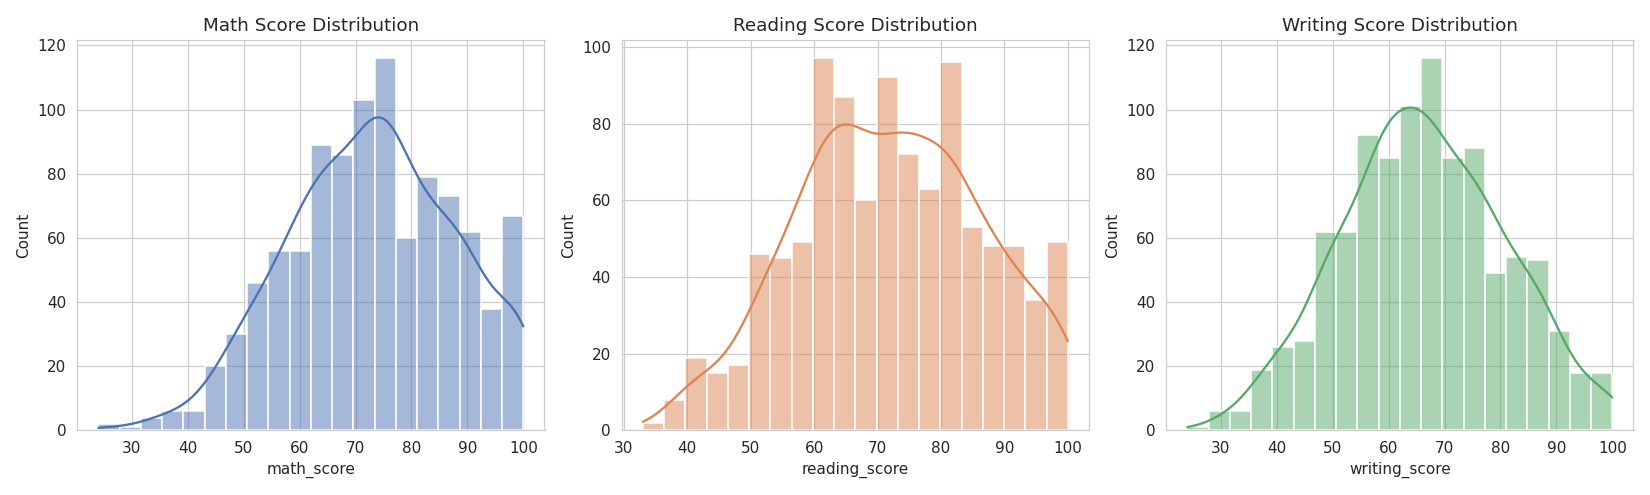

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, col, color in zip(axes, ["math_score", "reading_score", "writing_score"],
                           ["#4C72B0", "#DD8452", "#55A868"]):
    sns.histplot(df_clean[col], kde=True, ax=ax, color=color, bins=20)
    ax.set_title(f"{col.replace('_', ' ').title()} Distribution")
plt.tight_layout()
plt.show()


All three scores look roughly bell-shaped and centered in the high-60s/low-70s, with a bit of left skew (a tail of lower scorers) — pretty typical for exam data.

## 7. Does gender relate to performance?

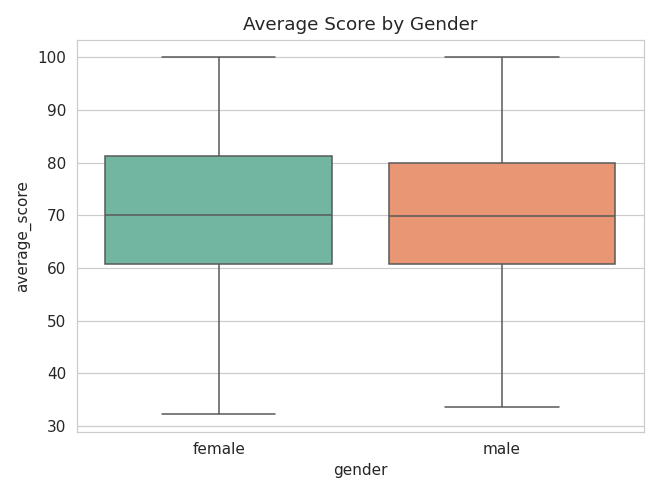

         math_score  reading_score  writing_score  average_score
gender                                                          
female        73.13          71.91          66.23          70.42
male          72.87          72.05          66.06          70.32

In [11]:
fig, ax = plt.subplots(figsize=(6, 4.5))
sns.boxplot(data=df_clean, x="gender", y="average_score", hue="gender", palette="Set2", ax=ax, legend=False)
ax.set_title("Average Score by Gender")
plt.tight_layout()
plt.show()

df_clean.groupby("gender")[["math_score","reading_score","writing_score","average_score"]].mean().round(2)


Barely any difference overall — average scores are within ~0.1 points of each other. Gender isn't a strong driver here in this dataset.

## 8. Test preparation course — does it actually help?

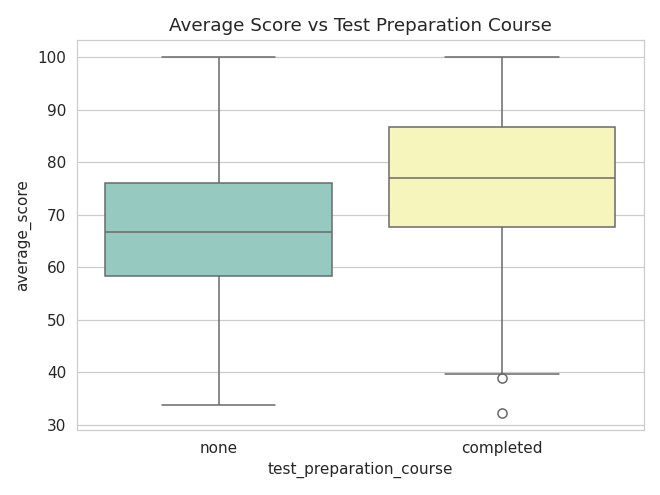

test_preparation_course
completed    76.16
none         67.22
Name: average_score, dtype: float64

In [12]:
fig, ax = plt.subplots(figsize=(6, 4.5))
sns.boxplot(data=df_clean, x="test_preparation_course", y="average_score",
            hue="test_preparation_course", palette="Set3", ax=ax, legend=False)
ax.set_title("Average Score vs Test Preparation Course")
plt.tight_layout()
plt.show()

df_clean.groupby("test_preparation_course")["average_score"].mean().round(2)


This one's a clear signal — students who **completed** the test prep course score about **9 points higher** on average than those who didn't. Out of everything in this dataset, this is probably the most actionable insight.

## 9. Parental education level

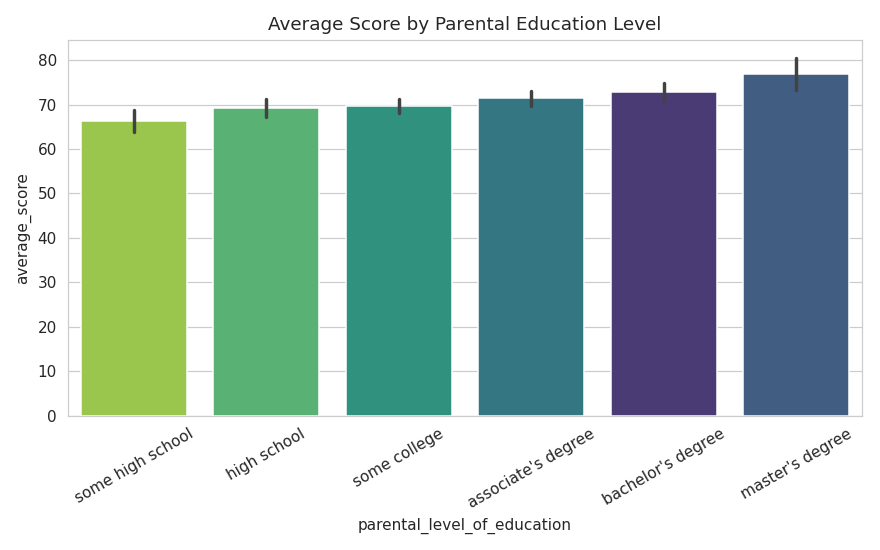

In [13]:
order = ["some high school", "high school", "some college",
         "associate's degree", "bachelor's degree", "master's degree"]

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=df_clean, x="parental_level_of_education", y="average_score",
            order=order, hue="parental_level_of_education", palette="viridis", ax=ax, legend=False)
ax.set_title("Average Score by Parental Education Level")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()


There's a steady upward trend — kids whose parents have a master's degree average about 10 points higher than kids whose parents didn't finish high school. Makes sense, and matches what's usually reported for the real version of this dataset too.

## 10. Correlation between numeric variables

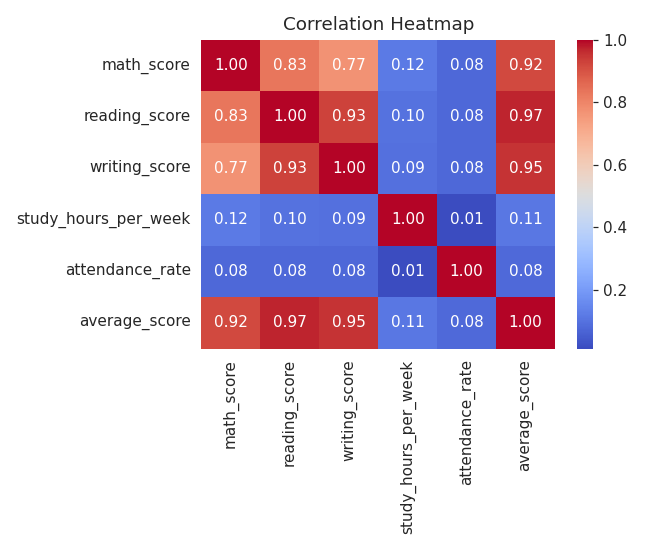

In [14]:
corr = df_clean[["math_score", "reading_score", "writing_score",
                  "study_hours_per_week", "attendance_rate", "average_score"]].corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", ax=ax)
ax.set_title("Correlation Heatmap")
plt.tight_layout()
plt.show()


The three subject scores are strongly correlated with each other (0.6–0.7-ish) — makes sense, a student who's strong in one subject tends to be strong across the board. Study hours and attendance have only a weak positive correlation with scores here, which was a little surprising — I expected a stronger link.

## 11. Study hours vs score

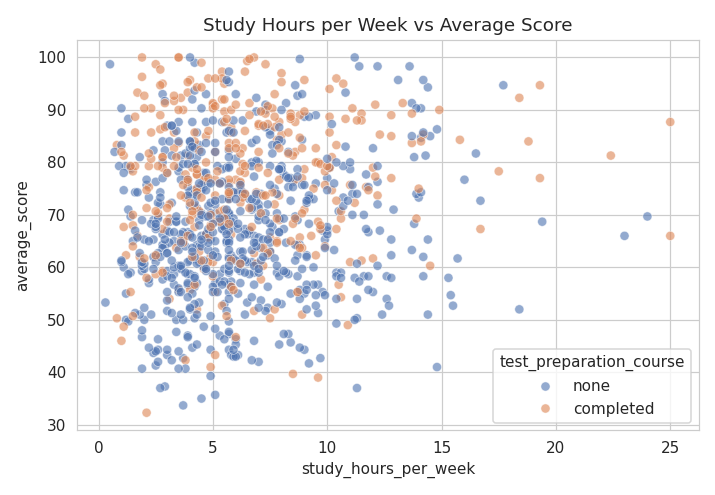

Correlation: 0.11


In [15]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
sns.scatterplot(data=df_clean, x="study_hours_per_week", y="average_score",
                 hue="test_preparation_course", palette="deep", alpha=0.6, ax=ax)
ax.set_title("Study Hours per Week vs Average Score")
plt.tight_layout()
plt.show()

print("Correlation:", df_clean["study_hours_per_week"].corr(df_clean["average_score"]).round(3))


## 12. Lunch type vs score

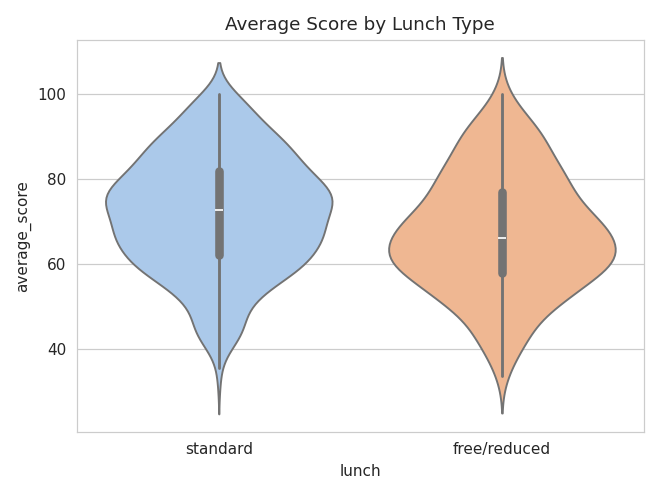

In [16]:
fig, ax = plt.subplots(figsize=(6, 4.5))
sns.violinplot(data=df_clean, x="lunch", y="average_score", hue="lunch", palette="pastel", ax=ax, legend=False)
ax.set_title("Average Score by Lunch Type")
plt.tight_layout()
plt.show()


Students on the standard lunch plan score noticeably higher on average than those on free/reduced lunch. This is a well-known pattern in the original Kaggle version of this dataset too — it's likely acting as a rough proxy for socio-economic background rather than the lunch itself having any direct effect.

## 13. Key Takeaways

- **Test preparation course completion** had the single biggest, cleanest effect: ~9 point average score bump.
- **Parental education level** shows a steady, almost linear relationship with average score.
- **Lunch type** (standard vs free/reduced) shows a meaningful gap, likely reflecting broader socio-economic factors rather than a direct effect of lunch itself.
- **Gender** showed almost no difference in this dataset.
- **Study hours and attendance** had only weak positive correlations with score — more hours logged didn't guarantee a big score jump, which suggests *quality*/consistency of studying (not captured here) probably matters more than raw hours.
- The three subject scores (math/reading/writing) are highly correlated with each other, meaning a student's overall academic strength tends to show up consistently across subjects rather than being subject-specific.

